In [1]:
# Cell 1: Upload data files
from google.colab import files
import os

# Create folder structure
os.makedirs('data/labeled', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Upload files
print("Upload train.csv, val.csv, test.csv")
uploaded = files.upload()

# Move to correct location
import shutil
for filename in uploaded.keys():
    shutil.move(filename, f'data/labeled/{filename}')
    print(f"Moved {filename} to data/labeled/")

print("Done!")

Upload train.csv, val.csv, test.csv


Saving test.csv to test.csv
Saving train.csv to train.csv
Saving val.csv to val.csv
Moved test.csv to data/labeled/
Moved train.csv to data/labeled/
Moved val.csv to data/labeled/
Done!


In [2]:
# Cell 2: Install libraries
!pip install transformers datasets peft accelerate -q

import torch
import transformers
import datasets
import peft

print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")
print(f"PEFT: {peft.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Datasets: 4.0.0
PEFT: 0.18.1
GPU available: True
GPU name: Tesla T4


In [3]:
# Cell 3: Baseline Test
from transformers import pipeline
import pandas as pd

# Load test data
test_df = pd.read_csv('data/labeled/test.csv')
print(f"Test set size: {len(test_df)} comments")

# Load a general multilingual sentiment model (no fine-tuning)
# This model only knows: 1-5 stars, not our 7 emotions
print("\nLoading baseline model...")
classifier = pipeline("sentiment-analysis",
                     model="nlptown/bert-base-multilingual-uncased-sentiment")

# Test on first 10 comments
print("\nBaseline Model Predictions:")
for i in range(10):
    comment = test_df.iloc[i]['comment_text']
    actual = test_df.iloc[i]['emotion']
    result = classifier(comment)[0]
    print(f"\nComment: {comment[:60]}...")
    print(f"Predicted: {result['label']} | Confidence: {result['score']:.2f}")
    print(f"Actual emotion: {actual}")

print("\n⚠️ Note: Baseline predicts star ratings, not our 7 emotions")
print("This is why we need fine-tuning!")

Test set size: 126 comments

Loading baseline model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Baseline Model Predictions:

Comment: That was brilliant run out? Seriously...
Predicted: 1 star | Confidence: 0.44
Actual emotion: SAR

Comment: Onek Moja chilo...
Predicted: 5 stars | Confidence: 0.44
Actual emotion: GP

Comment: Ai bedire dekhle aamr bumi ashe...
Predicted: 1 star | Confidence: 0.27
Actual emotion: ANG

Comment: a71 5 years using,,,,now still it❤️...
Predicted: 5 stars | Confidence: 0.68
Actual emotion: GP

Comment: Pakistani team was doing drama in t20 world cup for banglade...
Predicted: 4 stars | Confidence: 0.29
Actual emotion: GN

Comment: ডেলিভারি চার্জ কত...
Predicted: 3 stars | Confidence: 0.30
Actual emotion: NEU

Comment: ৩০ দিন করলে ভালো হবে...
Predicted: 5 stars | Confidence: 0.37
Actual emotion: CON

Comment: এত বড় একটা মেশিন গান এক হাতে লইয়া যাইতাচে কি শক্তি😂😂😂😂...
Predicted: 1 star | Confidence: 0.45
Actual emotion: SAR

Comment: দলীয় মতভেদ থাকবেই তার মানে এই নয় যে সবার কথাই ভিত্তিহীন। ন...
Predicted: 4 stars | Confidence: 0.31
Actual emotion: AN

In [4]:
# Cell 4: Prepare Data for Training

import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

# ── STEP 1: Load our CSV splits ──────────────────────────────
train_df = pd.read_csv('data/labeled/train.csv')
val_df   = pd.read_csv('data/labeled/val.csv')
test_df  = pd.read_csv('data/labeled/test.csv')
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── STEP 2: Convert emotion strings to numbers ───────────────
# Neural networks can't process strings like "SAR" or "GP"
# They only understand numbers, so we create a mapping:
# GP=0, GN=1, SAR=2, PA=3, ANG=4, CON=5, NEU=6
emotion_labels = ['GP', 'GN', 'SAR', 'PA', 'ANG', 'CON', 'NEU']
label2id = {label: i for i, label in enumerate(emotion_labels)}
id2label = {i: label for i, label in enumerate(emotion_labels)}
# label2id is used during training  (GP → 0)
# id2label is used during inference (0 → GP)

print("\nLabel mapping:", label2id)

# Add the numeric label column to each dataframe
train_df['label'] = train_df['emotion'].map(label2id)
val_df['label']   = val_df['emotion'].map(label2id)
test_df['label']  = test_df['emotion'].map(label2id)

# ── STEP 3: Convert pandas → HuggingFace Dataset format ──────
# HuggingFace Trainer expects Dataset objects, not pandas DataFrames
# We only keep 2 columns: the text and its numeric label
# Other columns (source_page, notes etc) are not needed for training
train_dataset = Dataset.from_pandas(train_df[['comment_text', 'label']])
val_dataset   = Dataset.from_pandas(val_df[['comment_text', 'label']])
test_dataset  = Dataset.from_pandas(test_df[['comment_text', 'label']])

# Bundle all 3 splits into one object for easy handling
dataset_dict = DatasetDict({
    'train':      train_dataset,
    'validation': val_dataset,
    'test':       test_dataset
})
print("\nDataset created:")
print(dataset_dict)

# ── STEP 4: Load the tokenizer ───────────────────────────────
# Tokenizer converts raw text into numbers the model understands
# Example: "ভালো product" → [3452, 7821, 1043]
# XLM-RoBERTa has its own vocabulary of ~250,000 tokens
# covering 100 languages including Bengali
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# ── STEP 5: Define tokenization function ─────────────────────
def tokenize_function(examples):
    return tokenizer(
        examples['comment_text'],
        padding='max_length',  # pad short comments with zeros to reach 128
        truncation=True,       # cut long comments at 128 tokens
        max_length=128         # 128 is enough for short FB comments
    )

# Apply tokenization to ALL splits at once (batched=True = faster)
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# ── STEP 6: Save to disk ─────────────────────────────────────
# So we don't re-tokenize every time we restart
# Tokenization takes ~1-2 min, saving it means next run is instant
import os
os.makedirs('data/processed', exist_ok=True)
tokenized_datasets.save_to_disk('data/processed/tokenized_data')

print("\n✅ Data prepared and tokenized!")
print(f"Train samples: {len(tokenized_datasets['train'])}")
print(f"Val samples:   {len(tokenized_datasets['validation'])}")
print(f"Test samples:  {len(tokenized_datasets['test'])}")

Train: 586 | Val: 126 | Test: 126

Label mapping: {'GP': 0, 'GN': 1, 'SAR': 2, 'PA': 3, 'ANG': 4, 'CON': 5, 'NEU': 6}

Dataset created:
DatasetDict({
    train: Dataset({
        features: ['comment_text', 'label'],
        num_rows: 586
    })
    validation: Dataset({
        features: ['comment_text', 'label'],
        num_rows: 126
    })
    test: Dataset({
        features: ['comment_text', 'label'],
        num_rows: 126
    })
})


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/126 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/586 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/126 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/126 [00:00<?, ? examples/s]


✅ Data prepared and tokenized!
Train samples: 586
Val samples:   126
Test samples:  126


In [18]:
# Cell 5 - REWRITE: No LoRA, direct fine-tuning
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

emotion_labels = ['GP', 'GN', 'SAR', 'PA', 'ANG', 'CON', 'NEU']
label2id = {label: i for i, label in enumerate(emotion_labels)}
id2label = {i: label for i, label in enumerate(emotion_labels)}

model_name = "xlm-roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=7,
    id2label=id2label,
    label2id=label2id
)

# Verify all parameters have gradients
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} = {100*trainable/total:.1f}%")

# Verify gradients flow
for name, param in list(model.named_parameters())[:3]:
    print(f"{name}: requires_grad={param.requires_grad}")

print("\n✅ Model ready for full fine-tuning!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 278,049,031 / 278,049,031 = 100.0%
classifier.dense.weight: requires_grad=True
classifier.dense.bias: requires_grad=True
classifier.out_proj.weight: requires_grad=True

✅ Model ready for full fine-tuning!


In [19]:
# Cell 6 - FIXED: Lower learning rate, more epochs
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': accuracy, 'f1': f1}

training_args = TrainingArguments(
    output_dir='models/checkpoints',
    num_train_epochs=10,               # increased from 3 to 10
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,                # reduced from 2e-4 to 2e-5
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none",
    warmup_steps=50,
    save_total_limit=2,
)

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

print("✅ Trainer configured!")
print(f"Total training steps: {len(tokenized_datasets['train']) // 16 * 10}")

✅ Trainer configured!
Total training steps: 360


In [20]:
# Cell 7: Start Training

import os
os.makedirs('models/checkpoints', exist_ok=True)
os.makedirs('models/logs', exist_ok=True)

print("🚀 Starting training...")
print("Watch the loss go down and f1 go up each epoch!\n")

# This one line does everything:
# - forward pass (predict)
# - calculate loss (how wrong was it)
# - backward pass (calculate gradients)
# - update weights (improve)
# - evaluate on val set after each epoch
# - save best checkpoint
trainer.train()

# Save the final best model
os.makedirs('models/final_model', exist_ok=True)
trainer.save_model('models/final_model')

# Save tokenizer alongside model so we can load both together later
tokenizer.save_pretrained('models/final_model')

print("\n✅ Training complete!")
print("Model saved to models/final_model")

🚀 Starting training...
Watch the loss go down and f1 go up each epoch!



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.926641,1.843485,0.238095,0.125754
2,1.797502,1.779954,0.253968,0.178716
3,1.721707,1.629153,0.357143,0.276656
4,1.537487,1.538831,0.428571,0.405370
5,1.453304,1.431008,0.484127,0.438753
6,1.276663,1.372283,0.531746,0.512869
7,1.235784,1.384209,0.484127,0.479002
8,1.023583,1.342266,0.563492,0.555568
9,0.911301,1.355809,0.531746,0.530708
10,0.909474,1.350681,0.547619,0.547066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training complete!
Model saved to models/final_model


Running predictions on test set...



Classification Report:
              precision    recall  f1-score   support

         ANG       0.46      0.33      0.39        18
         CON       0.47      0.50      0.48        14
          GN       0.38      0.29      0.33        17
          GP       0.60      0.80      0.69        30
         NEU       0.79      0.86      0.83        22
          PA       0.00      0.00      0.00         2
         SAR       0.52      0.48      0.50        23

    accuracy                           0.57       126
   macro avg       0.46      0.47      0.46       126
weighted avg       0.55      0.57      0.55       126



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


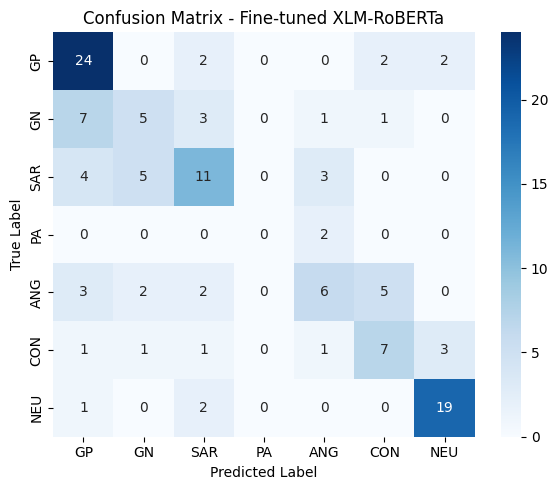


✅ Confusion matrix saved!


In [22]:
# Cell 8: Evaluate on Test Set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('outputs', exist_ok=True)

# ── STEP 1: Get predictions on test set ──────────────────────
# trainer.predict() runs the model on test set and returns predictions
print("Running predictions on test set...")
predictions = trainer.predict(tokenized_datasets['test'])

# predictions.predictions = raw logits (scores before softmax)
# argmax picks the highest scoring class for each comment
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Convert numbers back to emotion strings for readable report
id2label = {0: 'GP', 1: 'GN', 2: 'SAR', 3: 'PA', 4: 'ANG', 5: 'CON', 6: 'NEU'}
pred_emotions = [id2label[p] for p in pred_labels]
true_emotions = [id2label[t] for t in true_labels]

# ── STEP 2: Classification Report ────────────────────────────
# Shows precision, recall, f1 for each emotion class separately
print("\nClassification Report:")
print(classification_report(true_emotions, pred_emotions))

# ── STEP 3: Confusion Matrix ─────────────────────────────────
# Shows which emotions get confused with which
# Diagonal = correct predictions
# Off-diagonal = mistakes
emotion_order = ['GP', 'GN', 'SAR', 'PA', 'ANG', 'CON', 'NEU']
cm = confusion_matrix(true_emotions, pred_emotions, labels=emotion_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_order,
    yticklabels=emotion_order
)
plt.title('Confusion Matrix - Fine-tuned XLM-RoBERTa')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_day2.png', dpi=300)
plt.show()
print("\n✅ Confusion matrix saved!")

In [23]:
# Cell: Download files
from google.colab import files
import shutil

# Zip the model folder (too many files to download one by one)
shutil.make_archive('final_model', 'zip', 'models/final_model')
files.download('final_model.zip')

# Download confusion matrix
files.download('outputs/confusion_matrix_day2.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>